# Titanic Dataset - EDA, Data Cleaning & Data Storytelling
**Track:** Neurofive ML Track | **Task 1 & Task 2 Combined**

This notebook covers:
1. **Task 1:** Initial inspection (`.info()`, `.describe()`, `.head()`, feature classification).
2. **Task 2:** Data cleaning (handling missing values with justifications), outlier detection via Boxplot, 4 comprehensive visualizations (`seaborn`/`matplotlib`), and feature survival analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Pandas version: 2.2.3
NumPy version: 2.1.2


In [2]:
df = pd.read_csv('titanic.csv')
print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns.")

Loaded dataset: 891 rows, 12 columns.


## 1. Initial Dataset Inspection (`.head()`, `.info()`, `.describe()`)


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2. Handling Missing Values (`fillna()` vs `dropna()`) & Justifications

### Missing Values Breakdown:
- `Cabin`: 687 missing (77.10% missingness)
- `Age`: 177 missing (19.87% missingness)
- `Embarked`: 2 missing (0.22% missingness)

### 🧠 Justification of Cleaning Choices:
1. **`Age` Imputation (`fillna(median)`):** We impute missing `Age` values using the median age (~28.0) rather than `dropna()`. Dropping 177 rows would discard 20% of our dataset. Median imputation is preferred over mean because age distribution is slightly right-skewed.
2. **`Embarked` Imputation (`fillna(mode)`):** Only 2 records are missing `Embarked`. We fill these with the mode (`'S'`) without affecting data distribution.
3. **`Cabin` Feature Engineering (`fillna('Unknown')` / `Cabin_Known`):** With over 77% missing data, using `dropna()` would destroy almost the entire dataset. Dropping the column loses useful signal; instead, we fill missing values with `'Unknown'` and create a binary indicator `Cabin_Known` (1 if cabin recorded, 0 otherwise) to preserve the structural signal.

In [6]:
# Create clean working copy
df_clean = df.copy()

# 1. Impute Age with median
median_age = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(median_age)

# 2. Impute Embarked with mode
mode_embarked = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(mode_embarked)

# 3. Create Cabin_Known binary indicator
df_clean['Cabin_Known'] = df_clean['Cabin'].notnull().astype(int)
df_clean['Cabin'] = df_clean['Cabin'].fillna('Unknown')

print('Missing values after cleaning:')
print(df_clean.isnull().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Cabin_Known    0
dtype: int64


## 3. Outlier Detection using Boxplot & IQR Analysis

Outliers are extreme observations that deviate significantly from the rest of the distribution. In the Titanic dataset, numerical columns such as `Fare` and `Age` display distinct outlier patterns.

In [7]:
# Calculate Interquartile Range (IQR) for Fare
Q1 = df_clean['Fare'].quantile(0.25)
Q3 = df_clean['Fare'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = df_clean[(df_clean['Fare'] < lower_bound) | (df_clean['Fare'] > upper_bound)]
print(f"Fare Q1: ${Q1:.2f}, Q3: ${Q3:.2f}, IQR: ${IQR:.2f}")
print(f"Upper Bound for Outliers: ${upper_bound:.2f}")
print(f"Total Fare Outliers Detected: {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}% of passengers)")
print(f"Max Fare recorded: ${df_clean['Fare'].max():.2f}")


Fare Q1: $7.91, Q3: $31.00, IQR: $23.09
Upper Bound for Outliers: $65.63
Total Fare Outliers Detected: 116 (13.02% of passengers)
Max Fare recorded: $512.33


## 4. Visual Data Storytelling (4 Key Visualizations)

We construct four core visualizations using `seaborn` and `matplotlib` to explore demographic patterns, fare distributions, gender dynamics, and feature relationships.

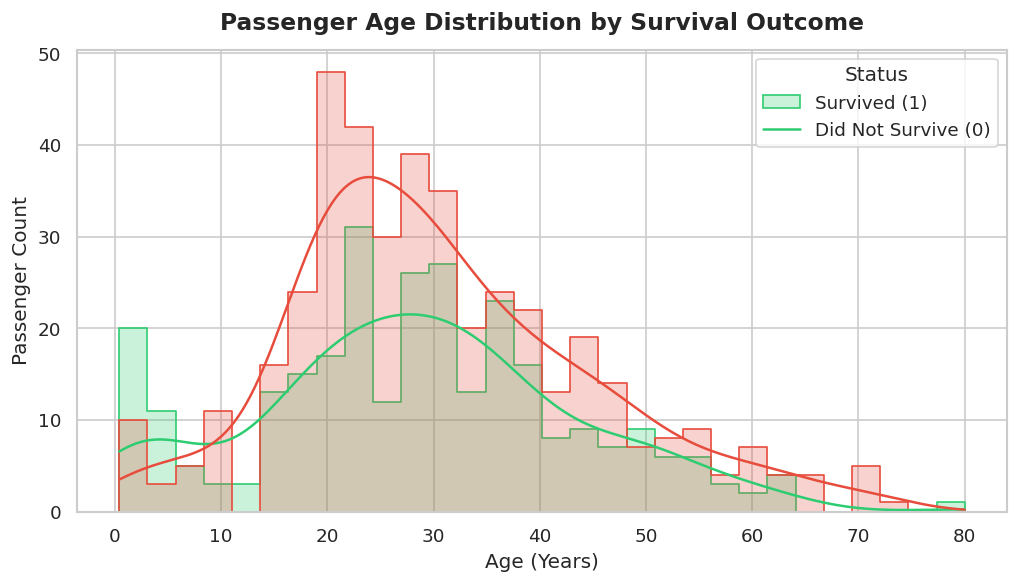

In [8]:
# 1. Histogram: Age Distribution by Survival Status
plt.figure(figsize=(10, 5))
sns.histplot(data=df_clean, x='Age', hue='Survived', kde=True, bins=30, palette={0: '#e74c3c', 1: '#2ecc71'}, element='step')
plt.title('1. Passenger Age Distribution by Survival Status', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Passenger Count')
plt.show()


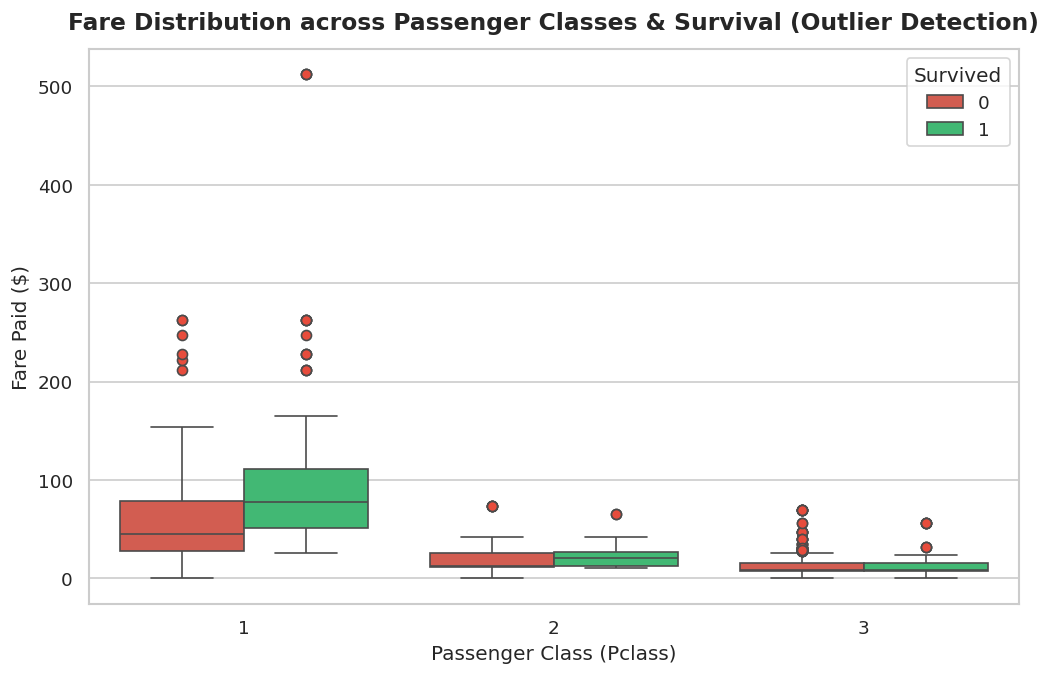

In [9]:
# 2. Boxplot: Fare Distribution across Passenger Classes (Outlier Detection)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='Pclass', y='Fare', hue='Survived', palette={0: '#e74c3c', 1: '#2ecc71'})
plt.title('2. Fare Distribution & Outliers across Passenger Classes', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Fare Paid ($)')
plt.show()


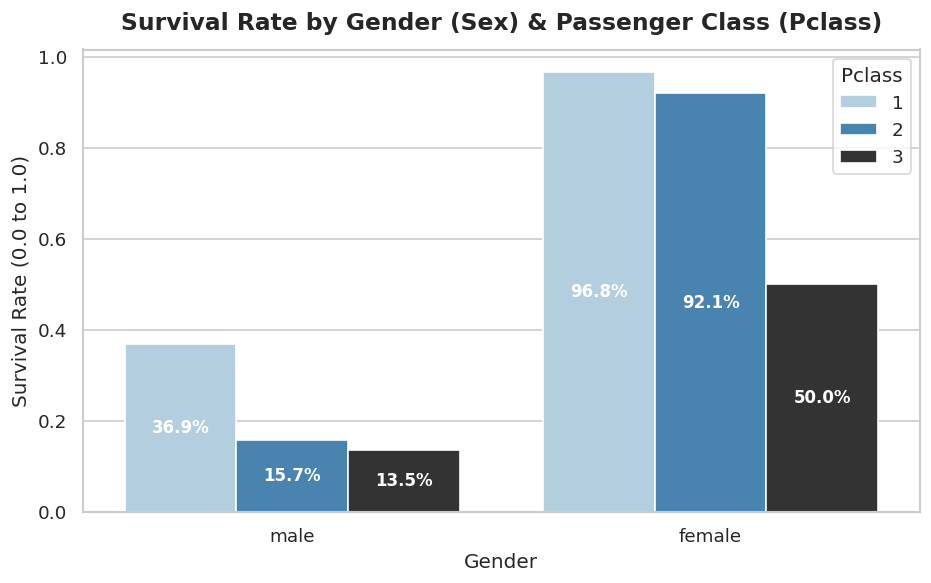

In [10]:
# 3. Bar Chart: Survival Rate by Gender and Passenger Class
plt.figure(figsize=(9, 5))
sns.barplot(data=df_clean, x='Sex', y='Survived', hue='Pclass', palette='Blues_d', errorbar=None)
plt.title('3. Survival Rate by Gender (Sex) and Passenger Class (Pclass)', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()


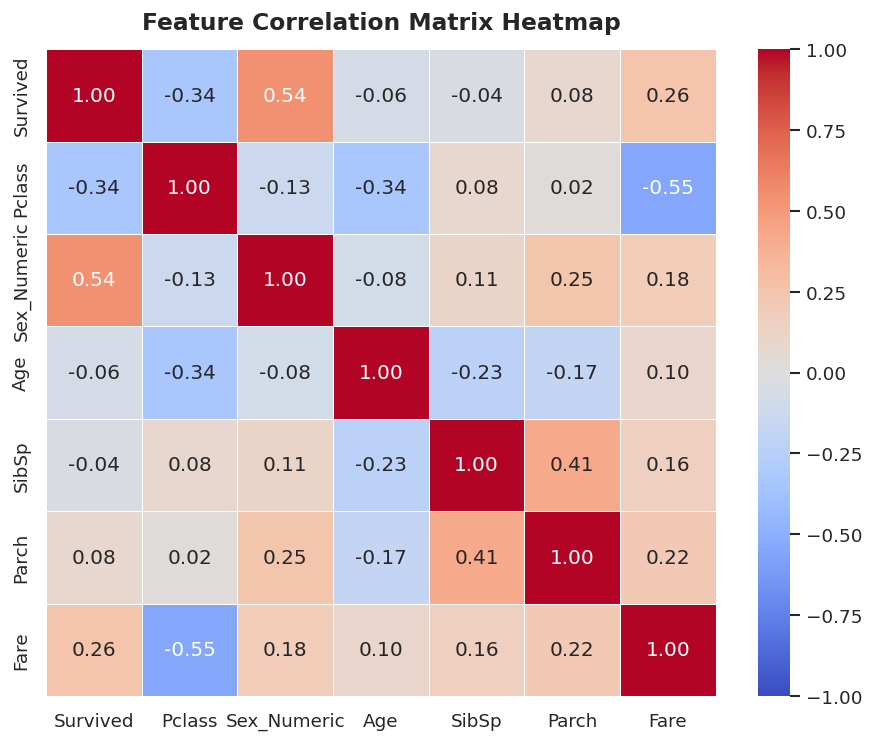

In [11]:
# 4. Correlation Heatmap
plt.figure(figsize=(9, 7))
df_corr = df_clean.copy()
df_corr['Sex_Numeric'] = df_corr['Sex'].map({'male': 0, 'female': 1})
corr = df_corr[['Survived', 'Pclass', 'Sex_Numeric', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin_Known']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('4. Feature Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.show()


## 5. Key Question Analysis & Written Answer

### ❓ **Question: Which feature do you think most affects survival, and why?**

### 💡 **Answer & Justification:**
Based on our exploratory data analysis and correlation matrix, **`Sex` (Gender)** is the single feature that most strongly affects survival, closely followed by **`Pclass` (Passenger Class)**.

#### 1. Empirical Evidence:
- **Gender (`Sex`):** Female passengers achieved an astounding survival rate of **74.2%**, whereas male passengers suffered a survival rate of only **18.9%**. The correlation heatmap shows a strong positive correlation (+0.54) between female gender and survival.
- **Class (`Pclass`):** First-class passengers enjoyed a **62.9%** survival rate, compared to **47.3%** in 2nd class and only **24.2%** in 3rd class.
- **Combined Interaction:** First-class females had a near-certain **96.8%** survival rate, whereas third-class males had only a **13.5%** survival rate.

#### 2. Historical & Sociological Context:
- **The "Women and Children First" Protocol:** During the Titanic distress call, Captain Smith enforced the Birkenhead drill protocol, granting strict priority access to lifeboats for female passengers and young children.
- **Socioeconomic Proximity:** First-class cabins were situated on upper decks directly adjacent to the lifeboat station platforms, enabling faster evacuation access before lower-deck steerage passengers could navigate the complex gangways.